In [19]:
import numpy as np
from numba import njit, prange


@njit(parallel=True, fastmath=True)
def calc_ecg_numba(tr_current, coords, i, j, k, dr, distance_power=1):

    n = coords.shape[0]
    ecg = np.empty(n, dtype=tr_current.dtype)

    for c in prange(n):
        x, y, z = coords[c]
        ds = (i - x) ** 2 + (j - y) ** 2 + (k - z) ** 2
        ds = np.where(ds == 0, 1, ds)
        d = np.sqrt(ds) ** distance_power
        ecg[c] = np.sum(tr_current / (d * dr))

    return ecg


x = np.random.random((500, 500))
i, j = np.where(x > -1)
k = np.zeros_like(i)

coords = np.random.random((100, 3)) * 100
dr = 1.0

calc_ecg_numba(x, coords, i, j, k, dr).shape

%timeit -n 100 -r 10 calc_ecg_numba(x, coords, i, j, k, dr)

935 μs ± 212 μs per loop (mean ± std. dev. of 10 runs, 100 loops each)


In [20]:
import numpy as np
import jax
import jax.numpy as jnp


@jax.jit
def calc_ecg_efficient(tr_current, coords, i, j, k, dr, distance_power=1.0):
    def body_fn(_, coord):
        x, y, z = coord
        ds = jnp.maximum((i - x)**2 + (j - y)**2 + (k - z)**2, 1e-9)
        d = jnp.sqrt(ds) ** distance_power
        result = jnp.sum(tr_current / (d * dr))
        return None, result

    # Scan loops on-device, keeping memory usage low
    _, ecg = jax.lax.scan(body_fn, None, coords)

    return ecg


@jax.jit
def calc_ecg_vmap(tr_current, coords, i, j, k, dr, distance_power=1.0):
    def single_coord_calc(coord):
        x, y, z = coord
        ds = (i - x) ** 2 + (j - y) ** 2 + (k - z) ** 2
        
        # Avoid division by zero: replace 0 with epsilon (much faster than jnp.where)
        ds = jnp.maximum(ds, 1e-9) 
        
        d = jnp.sqrt(ds) ** distance_power
        return jnp.sum(tr_current / (d * dr))

    # vmap removes the Python loop entirely
    return jax.vmap(single_coord_calc)(coords)

# Example usage
x = np.random.random((500, 500))
x = jnp.array(x)  # Convert to JAX array
i, j = jnp.where(x > -1)
k = jnp.zeros_like(i)

x = x.flatten()  # Flatten the array for easier indexing

coords = jnp.array(np.random.random((100, 3)) * 100)
dr = 1.0

calc_ecg_efficient(x, coords, i, j, k, dr).shape
calc_ecg_vmap(x, coords, i, j, k, dr).shape

%timeit -n 100 -r 10 calc_ecg_vmap(x, coords, i, j, k, dr)

3.15 ms ± 328 μs per loop (mean ± std. dev. of 10 runs, 100 loops each)


In [12]:
import mlx
import mlx.core as mx

@mx.compile
def body_fn(coord, tr_current, i, j, k, dr, distance_power):
    x, y, z = coord
    ds = mx.maximum((i - x)**2 + (j - y)**2 + (k - z)**2, 1)
    d = mx.sqrt(ds) ** distance_power
    result = mx.sum(tr_current / (d * dr))
    return result

def calc_ecg_mlx(tr_current, coords, i, j, k, dr, distance_power=1.0):
    in_axes=(0, None, None, None, None, None, None)
    ecg = mx.vmap(body_fn, in_axes=in_axes)(coords, tr_current, i, j, k, dr, distance_power)
    mx.eval(ecg)
    return ecg


x = np.random.random((500, 500))
i, j = np.where(x > -1)
k = np.zeros_like(i)

x = mx.array(x.flatten())
i, j, k = mx.array(i), mx.array(j), mx.array(k)
coords = mx.array(np.random.random((100, 3)) * 100)
dr = mx.array(1.0)
distance_power = mx.array(1.0)

%timeit -n 10 -r 10 calc_ecg_mlx(x, coords, i, j, k, dr, distance_power)

12.4 ms ± 161 μs per loop (mean ± std. dev. of 10 runs, 10 loops each)


Running AlievPanfilov on [100, 20] Grid: 100%|█████████▉| 7999/8000 [00:02<00:00, 3759.21it/s]


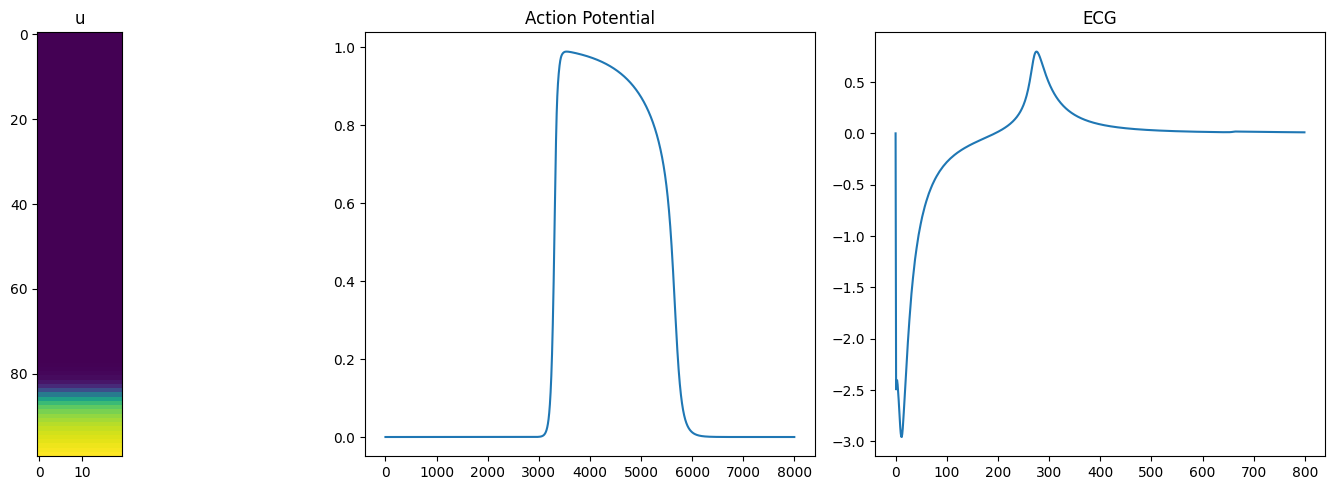

In [1]:
import matplotlib.pyplot as plt

import finitewave as fw
import numpy as np

# create a tissue of size 400x400 with cardiomycytes:
n = 100
m = 20
tissue = fw.CardiacTissue([n, m])

# stim_collection = fw.StimCurrentCoord(
#     time=0,
#     curr_value=10.0,
#     duration=.1,
#     x_min=0,
#     x_max=1,
#     y_min=0,
#     y_max=n,
# )

stim_collection = fw.StimVoltageCoord(
    time=0,
    volt_value=1.0,
    x_min=0,
    x_max=1,
    y_min=0,
    y_max=n,
)

stim_sequence = fw.StimSequence()
stim_sequence.add_stim(stim_collection)

diffusion_model = fw.GridModel()
diffusion_model.stencil = fw.IsotropicStencil()

ap_tracker = fw.ActionPotentialGridTracker()
ap_tracker.cell_ind = (n//2, m//2)
ap_tracker.start_time = 0.0

ecg_tracker = fw.ECGGridTracker()
ecg_tracker.start_time = 0.0
ecg_tracker.measure_coords = [(1, m//2, 1)]
ecg_tracker.step = 10


tracker_sequence = fw.TrackerSequence()
tracker_sequence.add_tracker(ap_tracker)
tracker_sequence.add_tracker(ecg_tracker)

# create model object and set up parameters:
simulation = fw.CardiacSimulation()
simulation.dt = 0.01
simulation.dr = 0.25
simulation.t_max = 80
simulation.cardiac_model = fw.AlievPanfilov()
simulation.cardiac_tissue = tissue
simulation.stim_sequence = stim_sequence
simulation.diffusion_model = diffusion_model
simulation.tracker_sequence = tracker_sequence

# run the model:
simulation.run()

voltage_list = ap_tracker.output[:]

# plt.figure()
# plt.imshow(simulation.diffusion_model.weights[0].toarray())
# plt.show()

# show the potential map at the end of calculations:
%matplotlib inline
fig, axs = plt.subplots(ncols=3, figsize=(15, 5))
axs[0].imshow(simulation.cardiac_model.u)
axs[0].set_title("u")
axs[1].plot(ap_tracker.output)
axs[1].set_title("Action Potential")
axs[2].plot(ecg_tracker.output)
axs[2].set_title("ECG")
plt.tight_layout()
plt.show()


Running AlievPanfilov on [100, 200] Grid: 100%|█████████▉| 3999/4000 [00:01<00:00, 2655.74it/s]


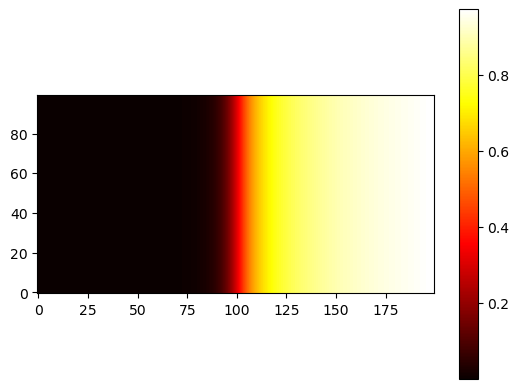

In [2]:
import matplotlib.pyplot as plt

import finitewave as fw
import numpy as np

# create a tissue of size 400x400 with cardiomycytes:
n = 100
m = 200
tissue = fw.CardiacTissue([n, m])
# tissue.mesh += (np.random.random(tissue.mesh.shape) < 0.2).astype(tissue.mesh.dtype)

# # set up stimulation parameters:
# stim = fw.StimVoltageCoord(time=0, volt_value=1,
#                            x_min=0, x_max=n,
#                            y_min=0, y_max=1)
# stim_collection = fw.StimVoltageCollection(start_time=0,
#                                            voltage_list=voltage_list,
#                                            duration=40)
# stim_collection.stimulation = stim

stim_collection = fw.StimCurrentCoord(
    time=0,
    curr_value=10.0,
    duration=.1,
    x_min=0,
    x_max=n,
    y_min=0,
    y_max=1,
)

stim_sequence = fw.StimSequence()
stim_sequence.add_stim(stim_collection)

diffusion_model = fw.GridAssembler()
diffusion_model.stencil = fw.IsotropicStencil()

egm_tracker = fw.ECGGridTracker([[n//2, 5, 1],
                                 [n//2, m//2, 1],
                                 [n//2, m-3, 1]],
                                 distance_power=2)
egm_tracker.start_time = 0.0


tracker_sequence = fw.TrackerSequence()
tracker_sequence.add_tracker(egm_tracker)

# create model object and set up parameters:
simulation = fw.CardiacSimulation()
simulation.dt = 0.01
simulation.dr = 0.25
simulation.t_max = 40
simulation.cardiac_model = fw.AlievPanfilov()
simulation.cardiac_tissue = tissue
simulation.stim_sequence = stim_sequence
simulation.diffusion_model = diffusion_model
simulation.tracker_sequence = tracker_sequence

# run the model:
simulation.run()

# plt.figure()
# plt.imshow(simulation.diffusion_model.weights[0].toarray())
# plt.show()

# show the potential map at the end of calculations:
%matplotlib inline
plt.figure()
plt.imshow(simulation.cardiac_model.u, origin='lower', cmap='hot')
plt.colorbar()
plt.show()


Running AlievPanfilov on [100, 200] Grid: 100%|█████████▉| 1499/1501 [00:00<00:00, 9102.07it/s]


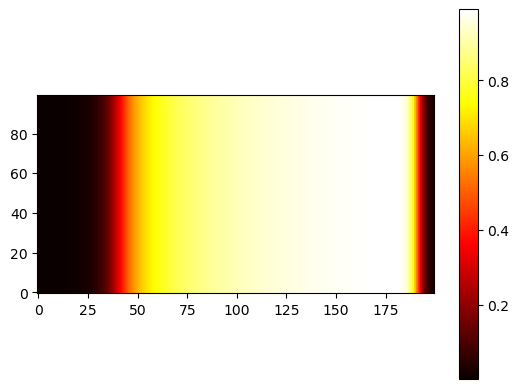

In [1]:
import matplotlib.pyplot as plt

import finitewave as fw
import numpy as np

# create a tissue of size 400x400 with cardiomycytes:
n = 100
m = 200
tissue = fw.CardiacTissue([n, m])
# tissue.mesh += (np.random.random(tissue.mesh.shape) < 0.2).astype(tissue.mesh.dtype)

# set up stimulation parameters:
stim = fw.StimVoltageCoord(time=0, volt_value=1,
                           x_min=0, x_max=n,
                           y_min=0, y_max=3)
stim_collection = fw.StimVoltageCollection(start_time=0,
                                           voltage_list=[1]*10,
                                           duration=0.09)
stim_collection.stimulation = stim

stim_sequence = fw.StimSequence()
stim_sequence.add_stim(stim_collection)

diffusion_model = fw.GridAssembler()
diffusion_model.stencil = fw.IsotropicStencil()

# create model object and set up parameters:
simulation = fw.CardiacSimulation()
simulation.dt = 0.01
simulation.dr = 0.25
simulation.t_max = 0.5
simulation.cardiac_model = fw.AlievPanfilov()
simulation.cardiac_tissue = tissue
simulation.stim_sequence = stim_sequence
simulation.diffusion_model = diffusion_model

# run the model:
simulation.run()
u_maps = []
u_maps.append(simulation.cardiac_model.u.copy())

simulation.t_max = 15
simulation.run(initialize=False)
u_maps.append(simulation.cardiac_model.u.copy())

simulation.t_max = 30
simulation.run(initialize=False)
u_maps.append(simulation.cardiac_model.u.copy())


# plt.figure()
# plt.imshow(simulation.diffusion_model.weights[0].toarray())
# plt.show()

# show the potential map at the end of calculations:
%matplotlib inline
plt.figure()
plt.imshow(simulation.cardiac_model.u, origin='lower', cmap='hot')
plt.colorbar()
plt.show()


In [3]:
def dr_model_to_mm(dr):
    cv_mm_ms = 0.6
    cv_model = 1.6 / 10
    # cv_model - dr
    # cv_mm_ms - res

    res = cv_mm_ms * dr / cv_model
    return res


def t_model_to_ms(t):
    return t * 10

dr = dr_model_to_mm(0.25)


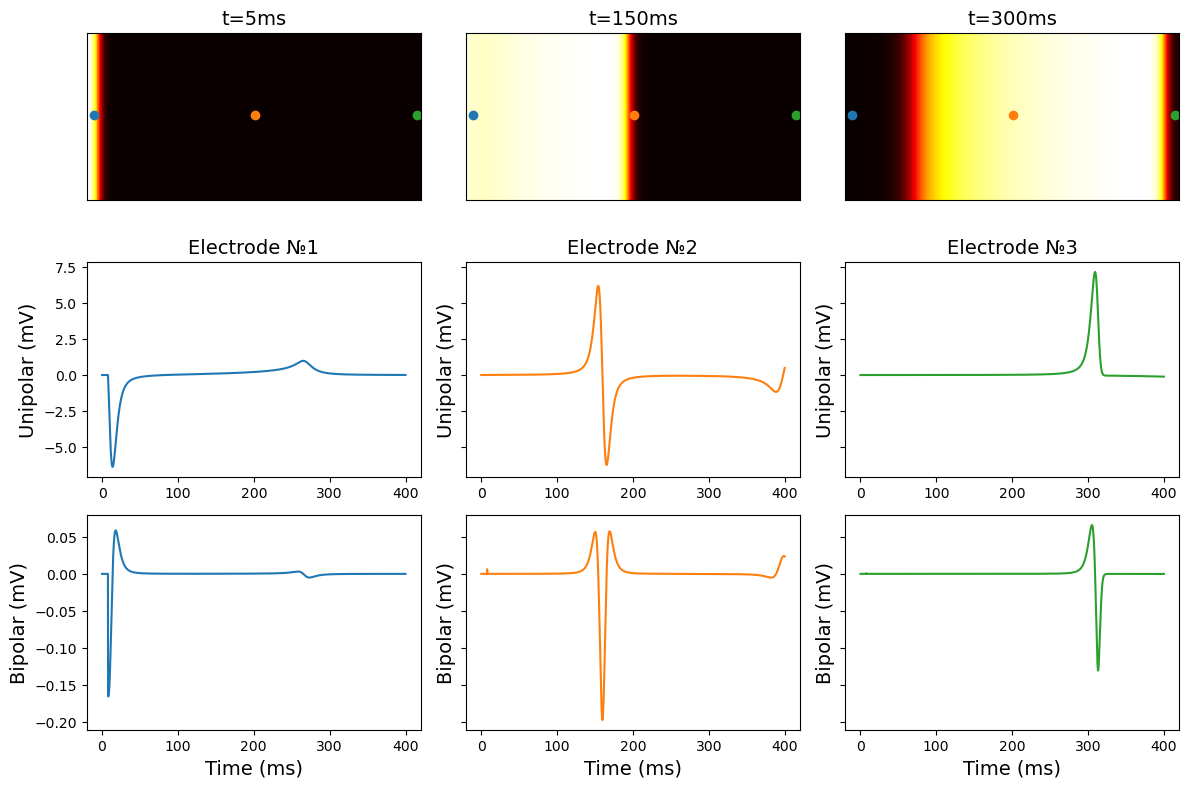

In [4]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'xtick.labelsize': 10,   # x-axis tick labels
    'ytick.labelsize': 10,   # y-axis tick labels
    'axes.labelsize': 14,    # axis labels (xlabel, ylabel)
    'axes.titlesize': 14,    # title size (optional)
    'figure.titlesize': 16,    # figure title size (optional)
    'lines.linewidth': 1.5
})


egm_points = np.array([[n//2, 3.5, 3], [n//2, m//2, 3], [n//2, m-3, 3]])

t_max = 40
t_list = [5, 150, 300]
egms = 100 / (4*np.pi) * egm_tracker.output * 0.25**2 / dr_model_to_mm(0.25) ** 2
egms[:79, :] = 0
# egms = egms[200:3400, :]
bi_egms = np.diff(egms, axis=0)
time_vector = np.arange(0, t_max, simulation.dt)[:] * 10

colors = ['tab:blue', 'tab:orange', 'tab:green']

%matplotlib inline
# make mosaic plot with potential map and EGM signals:
# first row: potential map
# second row: 3 plots with EGM signals
# third row: 3 plots with EGM signals' derivatives
fig, axs = plt.subplots(3, 3, figsize=(12, 8), sharex='row', sharey='row')
for i in range(3):
    axs[0, i].imshow(u_maps[i], origin='lower', cmap='hot')
    axs[0, i].set_title("t={:.0f}ms".format(t_list[i]))
    axs[0, i].scatter(egm_points[0, 1], egm_points[0, 0], color=colors[0])
    axs[0, i].scatter(egm_points[1, 1], egm_points[1, 0], color=colors[1])
    axs[0, i].scatter(egm_points[2, 1], egm_points[2, 0], color=colors[2])
    # axs[0, i].axis('off')
    axs[0, i].set_xticks([])
    axs[0, i].set_yticks([])
    axs[1, i].plot(time_vector, egms[:, i], color=colors[i])
    axs[1, i].set_title("Electrode №{}".format(i+1))
    # axs[1, i].set_xlabel("Time (ms)")
    axs[1, i].set_ylabel("Unipolar (mV)")
    axs[2, i].plot(time_vector[1:], bi_egms[:, i],
                   color=colors[i])
    # axs[2, i].set_title("Electrode №{}".format(i+1))
    axs[2, i].set_xlabel("Time (ms)")
    axs[2, i].set_ylabel("Bipolar (mV)")
plt.tight_layout()
plt.show()

In [94]:
fig.savefig("egm_signals.png", dpi=300)